In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import time 
from tqdm import tqdm

import jax
import jax.numpy as jnp
    
from dataclasses import dataclass


In [2]:
import nambu_class as nmb
import Eilenberger_methods as eil
import system_state as sys_state
import run_computation as comp
import custom_optimizer as copt

In [10]:
ntheta = 2
cutoff = 30 * eil.EilenbergerEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* eil.EilenbergerEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'theta_sampling': ntheta, 'cutoff': cutoff}
system_parameters = {'critical_temperature': 1.0, 'gap_symmetry' : 's'}
sigma_scatterings = {'Elastic': 0.1} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

my_eil = eil.EilenbergerEvolution(grid_parameters, system_parameters, sigma_scatterings = sigma_scatterings)

temperatures = jnp.linspace(0.1,1.2,10)
print(temperatures)

[0.1        0.22222222 0.34444445 0.4666667  0.58888894 0.7111111
 0.8333334  0.9555556  1.0777779  1.2       ]


In [11]:
gap_list = []
for temp in tqdm(temperatures):
    gaps = comp.calculate_equilibrium(temp_list = [temp], grid_parameters = grid_parameters, system_parameters = system_parameters, Q_list = [0], sigma_scatterings = sigma_scatterings)  
    gap_list +=[gaps]



100%|██████████| 10/10 [28:46<00:00, 172.65s/it]


In [13]:
print(gaps)

(1.764811e-05-0j)


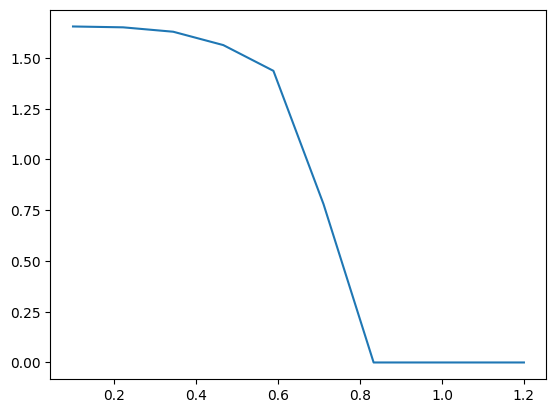

In [14]:
plt.plot(temperatures,jnp.abs(jnp.array(gap_list)))

In [7]:
plt.plot(temperatures,jnp.abs(jnp.array(gaps[:])))

IndexError: Too many indices: 0-dimensional array indexed with 1 regular index.